In [1]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [2]:
import pandas as pd
import numpy as np
import scipy.sparse as sp
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Libraries loaded successfully")

Libraries loaded successfully


In [3]:
df = pd.read_csv("/content/drive/MyDrive/FactLens_Group9/data/df_cleaned.csv")

print(f"Dataset loaded: {len(df)} articles")
print(df["label"].value_counts())

Dataset loaded: 38590 articles
label
REAL    21191
FAKE    17399
Name: count, dtype: int64


In [7]:
source_bias_words = [
    "reuters", "washington", "said", "told",
    "monday", "tuesday", "wednesday", "thursday",
    "friday", "saturday", "sunday",
    "jan", "feb", "mar", "apr", "jun",
    "jul", "aug", "sep", "oct", "nov", "dec",
    "via", "image", "video", "photo", "watch",
    "wire", "ap", "afp"
]

print(f"Total source bias words to remove: {len(source_bias_words)}")
print("\nWords that will be removed:")
print(source_bias_words)

Total source bias words to remove: 30

Words that will be removed:
['reuters', 'washington', 'said', 'told', 'monday', 'tuesday', 'wednesday', 'thursday', 'friday', 'saturday', 'sunday', 'jan', 'feb', 'mar', 'apr', 'jun', 'jul', 'aug', 'sep', 'oct', 'nov', 'dec', 'via', 'image', 'video', 'photo', 'watch', 'wire', 'ap', 'afp']


In [8]:
import re

def remove_bias_words(text, bias_words):
    words = str(text).split()
    cleaned = [w for w in words if w.lower() not in bias_words]
    return " ".join(cleaned)

print("Removing source bias words from all articles...")
df["debiased_text"] = df["cleaned_text"].apply(
    lambda x: remove_bias_words(x, source_bias_words)
)

# Compare before and after
print(f"\nAvg words BEFORE debiasing: {df['cleaned_text'].apply(lambda x: len(str(x).split())).mean():.0f}")
print(f"Avg words AFTER debiasing:  {df['debiased_text'].apply(lambda x: len(str(x).split())).mean():.0f}")

# Show example
print("\nBEFORE debiasing:")
print(df["cleaned_text"].iloc[0][:200])
print("\nAFTER debiasing:")
print(df["debiased_text"].iloc[0][:200])

Removing source bias words from all articles...

Avg words BEFORE debiasing: 228
Avg words AFTER debiasing:  221

BEFORE debiasing:
donald trump wish american happy new year leave instead give shout enemy hater dishonest fake news medium former reality show star one job country rapidly grows stronger smarter want wish friend suppo

AFTER debiasing:
donald trump wish american happy new year leave instead give shout enemy hater dishonest fake news medium former reality show star one job country rapidly grows stronger smarter want wish friend suppo


In [6]:
# Check if bias words actually appear in cleaned text
print("Checking bias words in cleaned text:")
for word in source_bias_words:
    count = df["cleaned_text"].str.contains(r'\b' + word + r'\b').sum()
    if count > 0:
        print(f"  '{word}' appears in {count:,} articles")
    else:
        print(f"  '{word}' NOT FOUND in cleaned text")

Checking bias words in cleaned text:
  'reuters' appears in 21,315 articles
  'washington' appears in 10,875 articles
  'said' appears in 29,509 articles
  'told' appears in 13,519 articles
  'monday' appears in 6,142 articles
  'tuesday' appears in 6,991 articles
  'wednesday' appears in 6,706 articles
  'thursday' appears in 6,505 articles
  'friday' appears in 6,267 articles
  'saturday' appears in 2,949 articles
  'sunday' appears in 3,689 articles
  'jan' appears in 1,202 articles
  'feb' appears in 507 articles
  'mar' appears in 71 articles
  'apr' appears in 14 articles
  'may' appears in 8,213 articles
  'jun' appears in 6 articles
  'jul' appears in 5 articles
  'aug' appears in 617 articles
  'sep' appears in 10 articles
  'oct' appears in 1,184 articles
  'nov' appears in 2,310 articles
  'dec' appears in 824 articles
  'via' appears in 9,253 articles
  'image' appears in 9,568 articles
  'video' appears in 4,587 articles
  'photo' appears in 1,456 articles
  'watch' appear

In [9]:
from sklearn.model_selection import train_test_split

# Prepare input and labels
X_text = df["debiased_text"]
y = df["label"]

# Apply TF-IDF
vectorizer_new = TfidfVectorizer(
    max_features=50000,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95
)

X_new = vectorizer_new.fit_transform(X_text)

print(f"New TF-IDF matrix shape: {X_new.shape}")

New TF-IDF matrix shape: (38590, 50000)


In [10]:
# Split
X_train_new, X_test_new, y_train_new, y_test_new = train_test_split(
    X_new, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"Training set: {X_train_new.shape[0]} articles")
print(f"Test set:     {X_test_new.shape[0]} articles")

# Train
print("\nTraining debiased model...")
model_new = LogisticRegression(
    C=1.0,
    max_iter=1000,
    random_state=42,
    class_weight="balanced",
    solver="lbfgs",
    n_jobs=-1
)

model_new.fit(X_train_new, y_train_new)
print("Training complete")

Training set: 30872 articles
Test set:     7718 articles

Training debiased model...
Training complete


In [11]:
y_pred_new = model_new.predict(X_test_new)

accuracy_new = accuracy_score(y_test_new, y_pred_new)

print("Debiased Model Results:")
print(f"Accuracy: {accuracy_new:.4f} ({accuracy_new:.2%})")
print("\nDetailed Classification Report:")
print(classification_report(y_test_new, y_pred_new))

Debiased Model Results:
Accuracy: 0.9750 (97.50%)

Detailed Classification Report:
              precision    recall  f1-score   support

        FAKE       0.98      0.97      0.97      3480
        REAL       0.97      0.98      0.98      4238

    accuracy                           0.97      7718
   macro avg       0.98      0.97      0.97      7718
weighted avg       0.98      0.97      0.97      7718



In [12]:
original_accuracy = 0.9852
debiased_accuracy = accuracy_new
difference = original_accuracy - debiased_accuracy

print("=" * 50)
print("COMPARISON — ORIGINAL vs DEBIASED MODEL")
print("=" * 50)
print(f"Original model accuracy:  {original_accuracy:.2%}")
print(f"Debiased model accuracy:  {debiased_accuracy:.2%}")
print(f"Accuracy difference:      {difference:.2%}")
print("=" * 50)

if difference > 0.05:
    print("\n✗ Large drop — model was heavily relying on source bias words")
elif difference > 0.02:
    print("\n⚠ Moderate drop — source bias had meaningful impact")
else:
    print("\n✓ Small drop — model learned real content signals too")

COMPARISON — ORIGINAL vs DEBIASED MODEL
Original model accuracy:  98.52%
Debiased model accuracy:  97.50%
Accuracy difference:      1.02%

✓ Small drop — model learned real content signals too


In [13]:
feature_names_new = vectorizer_new.get_feature_names_out()
coefficients_new = model_new.coef_[0]

coef_df_new = pd.DataFrame({
    "word": feature_names_new,
    "coefficient": coefficients_new
}).sort_values("coefficient", ascending=False)

print("TOP 20 FAKE INDICATORS AFTER DEBIASING:")
print("=" * 45)
for _, row in coef_df_new.head(20).iterrows():
    print(f"  {row['word']:30} {row['coefficient']:+.4f}")

print("\nTOP 20 REAL INDICATORS AFTER DEBIASING:")
print("=" * 45)
for _, row in coef_df_new.tail(20).sort_values("coefficient").iterrows():
    print(f"  {row['word']:30} {row['coefficient']:+.4f}")

TOP 20 FAKE INDICATORS AFTER DEBIASING:
  president donald               +8.4194
  statement                      +5.3472
  dont                           +5.3338
  representative                 +4.8465
  spokesman                      +4.8386
  im                             +4.6907
  minister                       +4.4529
  president barack               +4.1469
  thats                          +4.1339
  presidential                   +3.9280
  reporter                       +3.7697
  comment                        +3.7646
  obamas                         +3.6720
  london                         +3.6617
  democratic                     +3.6225
  he                             +3.5471
  moscow                         +3.5034
  house representative           +3.2829
  news conference                +3.2454
  republican presidential        +3.1795

TOP 20 REAL INDICATORS AFTER DEBIASING:
  gop                            -6.6135
  even                           -6.2826
  like           

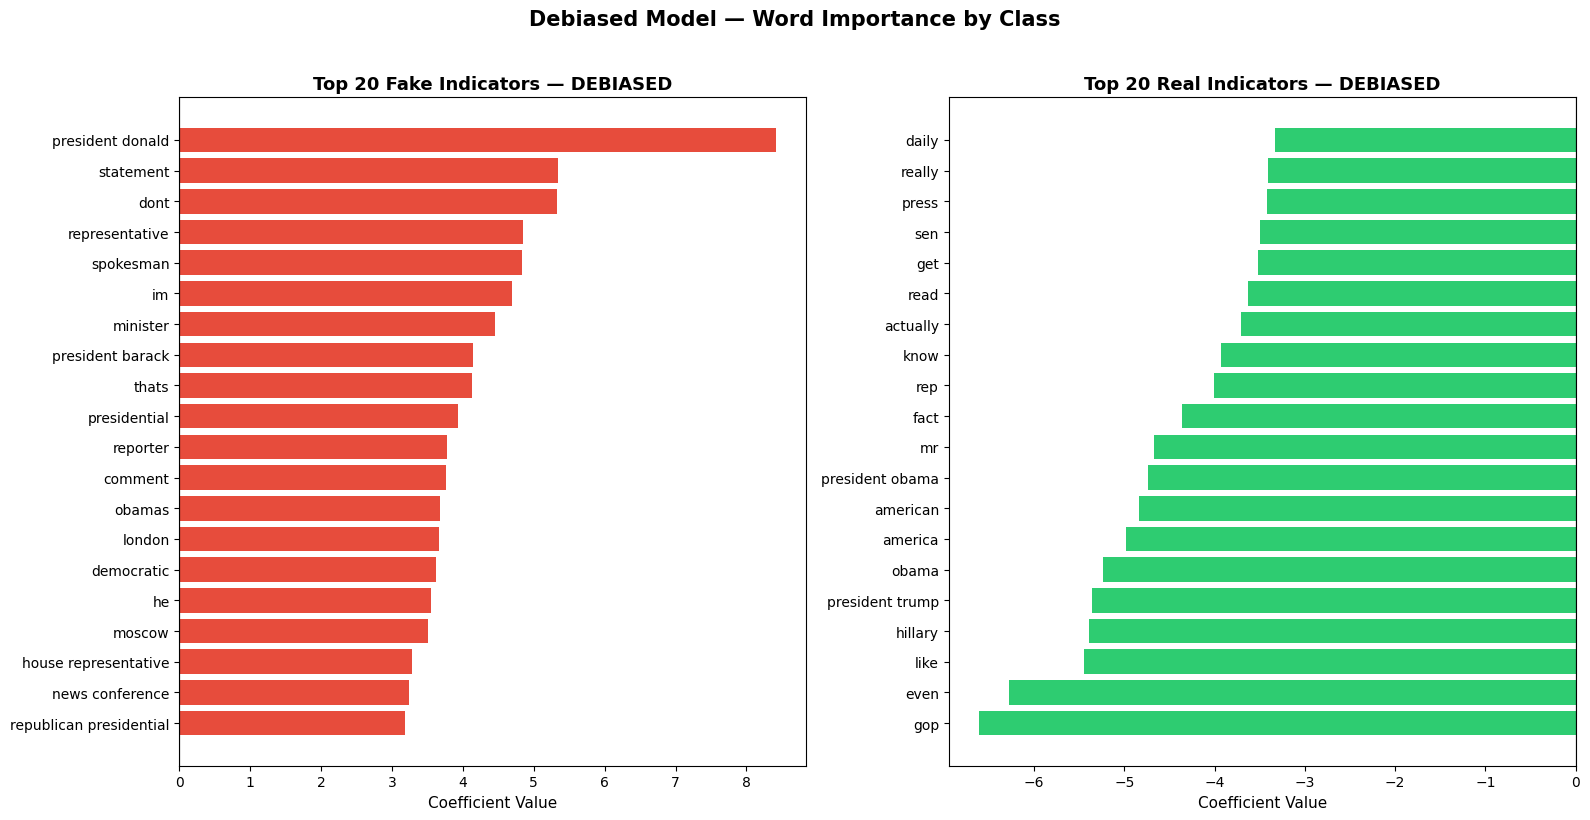

In [14]:
top_fake_new = coef_df_new.head(20)
top_real_new = coef_df_new.tail(20).sort_values("coefficient")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))

ax1.barh(top_fake_new["word"][::-1],
         top_fake_new["coefficient"][::-1],
         color="#E74C3C")
ax1.set_title("Top 20 Fake Indicators — DEBIASED",
              fontsize=13, fontweight="bold")
ax1.set_xlabel("Coefficient Value", fontsize=11)
ax1.axvline(x=0, color="black", linewidth=0.8)

ax2.barh(top_real_new["word"],
         top_real_new["coefficient"],
         color="#2ECC71")
ax2.set_title("Top 20 Real Indicators — DEBIASED",
              fontsize=13, fontweight="bold")
ax2.set_xlabel("Coefficient Value", fontsize=11)
ax2.axvline(x=0, color="black", linewidth=0.8)

plt.suptitle("Debiased Model — Word Importance by Class",
             fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/FactLens_Group9/data/debiased_word_importance.png",
            dpi=150, bbox_inches="tight")
plt.show()